# Analiza Ról Użytkowników w Debatach Dezinformacyjnych
## Projekt: Kto napędza dyskusję?

**Cel:** Profilowanie ról użytkowników i pomiar "temperatury" dyskusji w subredditach

---

### Metodologia:
1. **Data Engineering** - Rekonstrukcja sieci interakcji
2. **Feature Engineering** - Wyliczenie cech użytkowników
3. **Temperature Index** - Metryka intensywności sporu
4. **Clustering** - Identyfikacja ról (K-Means)
5. **Wizualizacja** - Graf sieciowy z kolorami klastrów

## 📚 ETAP 1: Import Bibliotek i Wczytanie Danych

Instalujemy i importujemy wszystkie potrzebne biblioteki do analizy sieciowej, NLP i ML.

In [1]:
# Instalacja wymaganych pakietów (uruchom jednokrotnie)
import sys
!{sys.executable} -m pip install -q pandas numpy networkx scikit-learn matplotlib seaborn nltk textblob tqdm pyvis

# Pobieranie leksykonów VADER dla analizy sentymentu
import nltk
nltk.download('vader_lexicon', quiet=True)
print("✓ Wszystkie pakiety zainstalowane (w tym tqdm i pyvis)")

c:\Users\barrt\PycharmProjects\disinformation\.venv\Scripts\python.exe: No module named pip


✓ Wszystkie pakiety zainstalowane (w tym tqdm i pyvis)


In [2]:
# Import standardowych bibliotek
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# NLP - Analiza sentymentu
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Ustawienia wizualizacji
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("✓ Biblioteki zaimportowane")

✓ Biblioteki zaimportowane


In [3]:
# Wczytanie danych z CSV
# UWAGA: Zmień ścieżkę na właściwą dla Twojego pliku
data_path = '../data/data_dump202601082211.csv'

df = pd.read_csv(data_path)

# Konwersja timestamp na datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Pierwsze spojrzenie na dane
print(f"📊 Załadowano {len(df)} wierszy")
print(f"📅 Zakres czasowy: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"👥 Liczba unikalnych autorów: {df['author'].nunique()}")
print(f"💬 Typy aktywności: {df['activity_type'].value_counts().to_dict()}")

# Podgląd struktury
df.head()

📊 Załadowano 34030 wierszy
📅 Zakres czasowy: 2014-01-26 21:00:24+00:00 → 2026-01-08 16:03:03+00:00
👥 Liczba unikalnych autorów: 14045
💬 Typy aktywności: {'comment': 33649, 'post': 381}


,activity_id,activity_type,timestamp,subreddit,author,parent_id,parent_type,content,permalink,score,upvotes,downvotes,upvote_ratio,num_comments,edited
0,t3_16i88dt,post,2023-09-14 04:03:43+00:00,aliens,imaginexus,NaN,NaN,A good summary from X on the alien mummy situa...,https://www.reddit.com/r/aliens/comments/16i88...,2063,2063,0.0,0.56,2764.0,False
1,t1_k0i921c,comment,2023-09-14 04:03:44+00:00,aliens,AutoModerator,t3_16i88dt,post,__Reminder__: Read the rules and understand th...,https://www.reddit.com/r/aliens/comments/16i88...,1,1,NaN,NaN,NaN,False
2,t1_k0irteh,comment,2023-09-14 07:28:15+00:00,aliens,Jasonclark2,t3_16i88dt,post,![gif](giphy|7ziXfljX6nkpGPndlm),https://www.reddit.com/r/aliens/comments/16i88...,243,243,NaN,NaN,NaN,False
3,t1_k0j3ghu,comment,2023-09-14 10:02:13+00:00,aliens,angomania,t3_16i88dt,post,"""UPDATE: I've investigated further, and I've d...",https://www.reddit.com/r/aliens/comments/16i88...,1174,1174,NaN,NaN,NaN,False
4,t1_k0ja5eq,comment,2023-09-14 11:16:27+00:00,aliens,NaN,t3_16i88dt,post,The coping in these comments is real,https://www.reddit.com/r/aliens/comments/16i88...,80,80,NaN,NaN,NaN,False


## 🔗 ETAP 2: Data Engineering - Rekonstrukcja Sieci Interakcji

**Problem:** Kolumna `parent_id` wskazuje na activity_id rodzica, ale nie mamy bezpośrednio informacji o autorze, do którego kierowany jest komentarz.

**Rozwiązanie:** Tworzymy mapowanie `activity_id → author`, a następnie dla każdego komentarza znajdujemy `target_author` przez lookup `parent_id`.

In [4]:
# KROK 1: Czyszczenie danych - usunięcie botów i usuniętych użytkowników
print("🧹 Czyszczenie danych...")

initial_count = len(df)
df = df[~df['author'].isin(['[deleted]', '[removed]', 'AutoModerator'])].copy()
df = df[df['author'].notna()].copy()

print(f"  Usunięto {initial_count - len(df)} wierszy (boty, usunięci użytkownicy)")
print(f"  Pozostało: {len(df)} aktywności od {df['author'].nunique()} użytkowników")

🧹 Czyszczenie danych...
  Usunięto 5908 wierszy (boty, usunięci użytkownicy)
  Pozostało: 28122 aktywności od 14044 użytkowników


In [5]:
# KROK 2: Stworzenie mapowania activity_id → author (SELF-JOIN)
print("🗺️ Tworzenie mapowania interakcji...")

# Słownik: każde activity_id mapuje na swojego autora
activity_to_author = dict(zip(df['activity_id'], df['author']))

# Funkcja pomocnicza do znalezienia target_author
def find_target_author(parent_id):
    """Znajduje autora, do którego skierowana jest odpowiedź"""
    if pd.isna(parent_id) or parent_id == 'N/A':
        return None
    return activity_to_author.get(parent_id, None)

# Dodanie kolumny target_author do DataFrame
df['target_author'] = df['parent_id'].apply(find_target_author)

# Statystyki interakcji
interactions = df[df['target_author'].notna()]
print(f"  ✓ Zrekonstruowano {len(interactions)} interakcji między użytkownikami")
print(f"  ✓ {len(df[df['target_author'].isna()])} aktywności bez target_author (nowe posty)")

🗺️ Tworzenie mapowania interakcji...
  ✓ Zrekonstruowano 22974 interakcji między użytkownikami
  ✓ 5148 aktywności bez target_author (nowe posty)


In [6]:
# KROK 3: Budowa skierowanego grafu (DiGraph) z wagami
print("🕸️ Budowa grafu interakcji...")

G = nx.DiGraph()

# Dodanie wszystkich użytkowników jako węzłów
all_users = set(df['author'].unique())
G.add_nodes_from(all_users)

# Dodanie krawędzi: author → target_author (komentarz/odpowiedź)
# Z wagami: zliczamy ile razy A odpowiada B
edges = []
for _, row in interactions.iterrows():
    if row['target_author'] and row['author'] != row['target_author']:
        edges.append((row['author'], row['target_author']))

# Zliczanie wag (ile razy użytkownik A odpowiedział użytkownikowi B)
edge_weights = Counter(edges)

for (u, v), weight in edge_weights.items():
    G.add_edge(u, v, weight=weight)

print(f"  ✓ Graf utworzony:")
print(f"    - Węzły (użytkownicy): {G.number_of_nodes()}")
print(f"    - Krawędzie (interakcje): {G.number_of_edges()}")
print(f"    - Krawędzie ważone: tak (max waga: {max(edge_weights.values())})")
print(f"    - Średni stopień węzła: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

🕸️ Budowa grafu interakcji...
  ✓ Graf utworzony:
    - Węzły (użytkownicy): 14044
    - Krawędzie (interakcje): 20246
    - Krawędzie ważone: tak (max waga: 22)
    - Średni stopień węzła: 2.88


## 🔬 ETAP 3: Feature Engineering - Profilowanie Użytkowników

Dla każdego użytkownika wyliczamy zestaw cech, które posłużą do klasteryzacji:
- **Aktywność:** liczba postów, komentarzy, stosunek post/comment
- **Sieć:** in-degree, out-degree, PageRank
- **Sentyment:** średnia i odchylenie standardowe (VADER)
- **Kontrowersja:** średnie upvote_ratio i score

In [7]:
# Przygotowanie analizatora sentymentu
print("💭 Inicjalizacja analizy sentymentu (VADER)...")
sia = SentimentIntensityAnalyzer()

# Import tqdm dla paska postępu
from tqdm.notebook import tqdm
tqdm.pandas()

def get_sentiment(text):
    """Zwraca wynik sentymentu (compound score od -1 do 1)"""
    if pd.isna(text) or text == '[deleted]':
        return 0.0
    try:
        return sia.polarity_scores(str(text))['compound']
    except:
        return 0.0

# Dodanie kolumny sentymentu do DataFrame z paskiem postępu
print("  Obliczanie sentymentu dla wszystkich wypowiedzi...")
df['sentiment'] = df['content'].progress_apply(get_sentiment)
print(f"  ✓ Sentiment score: min={df['sentiment'].min():.2f}, max={df['sentiment'].max():.2f}, mean={df['sentiment'].mean():.2f}")

💭 Inicjalizacja analizy sentymentu (VADER)...
  Obliczanie sentymentu dla wszystkich wypowiedzi...


  0%|          | 0/28122 [00:00<?, ?it/s]

  ✓ Sentiment score: min=-1.00, max=1.00, mean=0.06


In [8]:
# Wyliczanie cech dla każdego użytkownika
print("📊 Wyliczanie cech użytkowników...")

user_features = {}

for author in df['author'].unique():
    user_data = df[df['author'] == author]
    
    # 1. CECHY AKTYWNOŚCI
    num_posts = len(user_data[user_data['activity_type'] == 'post'])
    num_comments = len(user_data[user_data['activity_type'] == 'comment'])
    total_activity = num_posts + num_comments
    post_ratio = num_posts / total_activity if total_activity > 0 else 0
    
    # 2. CECHY SIECIOWE
    in_degree = G.in_degree(author) if author in G else 0  # Ile osób mu odpisuje (autorytet)
    out_degree = G.out_degree(author) if author in G else 0  # Ile on odpisuje innym
    
    # 3. CECHY SENTYMENTU
    sentiments = user_data['sentiment'].dropna()
    avg_sentiment = sentiments.mean() if len(sentiments) > 0 else 0
    std_sentiment = sentiments.std() if len(sentiments) > 1 else 0
    
    # 4. CECHY KONTROWERSJI
    # upvote_ratio blisko 0.5 = duża kontrowersja (równe up i downvotes)
    ratios = user_data['upvote_ratio'].dropna()
    avg_upvote_ratio = ratios.mean() if len(ratios) > 0 else 0.5
    
    scores = user_data['score'].dropna()
    avg_score = scores.mean() if len(scores) > 0 else 0
    
    user_features[author] = {
        'num_posts': num_posts,
        'num_comments': num_comments,
        'total_activity': total_activity,
        'post_ratio': post_ratio,
        'in_degree': in_degree,
        'out_degree': out_degree,
        'avg_sentiment': avg_sentiment,
        'std_sentiment': std_sentiment,
        'avg_upvote_ratio': avg_upvote_ratio,
        'avg_score': avg_score
    }

# Konwersja do DataFrame
user_df = pd.DataFrame.from_dict(user_features, orient='index')

print(f"  ✓ Wyliczono cechy dla {len(user_df)} użytkowników")
print(f"\n📈 Przegląd statystyk:")
user_df.describe().T

📊 Wyliczanie cech użytkowników...
  ✓ Wyliczono cechy dla 14044 użytkowników

📈 Przegląd statystyk:


,count,mean,std,min,25%,50%,75%,max
num_posts,14044.0,0.024210,0.212775,0.0000,0.000000,0.0,0.000000,11.000000
num_comments,14044.0,1.978211,3.590394,0.0000,1.000000,1.0,2.000000,222.000000
total_activity,14044.0,2.002421,3.649922,1.0000,1.000000,1.0,2.000000,222.000000
post_ratio,14044.0,0.007844,0.075110,0.0000,0.000000,0.0,0.000000,1.000000
in_degree,14044.0,1.441612,9.787899,0.0000,0.000000,0.0,1.000000,675.000000
out_degree,14044.0,1.441612,1.930818,0.0000,1.000000,1.0,1.000000,56.000000
avg_sentiment,14044.0,0.046322,0.391335,-0.9996,-0.134763,0.0,0.318200,0.995400
std_sentiment,14044.0,0.120784,0.223830,0.0000,0.000000,0.0,0.178127,1.352483
avg_upvote_ratio,14044.0,0.500279,0.007075,0.4000,0.500000,0.5,0.500000,0.720000
avg_score,14044.0,10.625373,71.531453,-30.5000,1.000000,2.0,5.000000,4114.000000


In [9]:
# Dodanie PageRank (autorytet w sieci)
print("🏆 Obliczanie PageRank...")

# PageRank wymaga grafu z przynajmniej jedną krawędzią
if G.number_of_edges() > 0:
    pagerank = nx.pagerank(G, alpha=0.85)
    user_df['pagerank'] = user_df.index.map(pagerank).fillna(0)
else:
    user_df['pagerank'] = 0

print(f"  ✓ PageRank: top użytkownik ma score {user_df['pagerank'].max():.6f}")
print(f"\n🎯 TOP 10 użytkowników wg PageRank:")
user_df.nlargest(10, 'pagerank')[['total_activity', 'in_degree', 'out_degree', 'pagerank']]

🏆 Obliczanie PageRank...
  ✓ PageRank: top użytkownik ma score 0.014086

🎯 TOP 10 użytkowników wg PageRank:


,total_activity,in_degree,out_degree,pagerank
Pleasant-Lie-9053,45,204,25,0.014086
littlespacemochi,20,675,3,0.011073
matt73132,10,164,5,0.010319
TheDog00,23,273,19,0.009960
DragonfruitOdd1989,26,267,7,0.009208
imaginexus,26,176,19,0.008942
Tamarama---,38,151,27,0.007711
malemysteries,19,282,17,0.007259
SpinRed,43,45,18,0.006329
Streay,19,197,9,0.005927


## 🌡️ ETAP 4: Temperatura Dyskusji (Discussion Temperature Index)

Temperatura dyskusji to metryka intensywności konfliktu, uwzględniająca:
- **Volume** (objętość komentarzy)
- **Negative Sentiment** (natężenie negatywnych emocji)
- **Controversy** (polaryzacja wyrażona przez upvote_ratio)

$$T = 0.4 \times \text{NormVolume} + 0.4 \times \text{NegSent} + 0.2 \times \text{InvRatio}$$

In [10]:
# Resampling danych co 4 godziny
print("🌡️ Obliczanie temperatury dyskusji...")

df_temp = df.set_index('timestamp').copy()

# Agregacja w interwałach 4-godzinnych
temperature_data = []

for window, group in df_temp.resample('4H'):
    if len(group) == 0:
        continue
    
    # 1. Normalized Volume - liczba komentarzy w oknie
    volume = len(group)
    
    # 2. Negative Sentiment Intensity - średnia z wartości ujemnych
    neg_sentiments = group['sentiment'][group['sentiment'] < 0]
    neg_intensity = abs(neg_sentiments.mean()) if len(neg_sentiments) > 0 else 0
    
    # 3. Inverse Upvote Ratio - odległość od 0.5 (im bliżej 0.5, tym więcej kontrowersji)
    ratios = group['upvote_ratio'].dropna()
    if len(ratios) > 0:
        # Im bliżej 0.5, tym wyższy wskaźnik kontrowersji
        controversy = 1 - 2 * abs(ratios.mean() - 0.5)  # 0.5 → 1.0, 0 lub 1 → 0.0
    else:
        controversy = 0
    
    temperature_data.append({
        'timestamp': window,
        'volume': volume,
        'neg_intensity': neg_intensity,
        'controversy': controversy
    })

temp_df = pd.DataFrame(temperature_data)

# Normalizacja volume do [0, 1]
if temp_df['volume'].max() > 0:
    temp_df['norm_volume'] = temp_df['volume'] / temp_df['volume'].max()
else:
    temp_df['norm_volume'] = 0

# Obliczenie TEMPERATURY
temp_df['temperature'] = (
    temp_df['norm_volume'] * 0.4 +
    temp_df['neg_intensity'] * 0.4 +
    temp_df['controversy'] * 0.2
)

print(f"  ✓ Wyliczono temperaturę dla {len(temp_df)} okien czasowych")
print(f"  📈 Temperatura: min={temp_df['temperature'].min():.3f}, max={temp_df['temperature'].max():.3f}, avg={temp_df['temperature'].mean():.3f}")

🌡️ Obliczanie temperatury dyskusji...
  ✓ Wyliczono temperaturę dla 2531 okien czasowych
  📈 Temperatura: min=0.002, max=0.809, avg=0.163


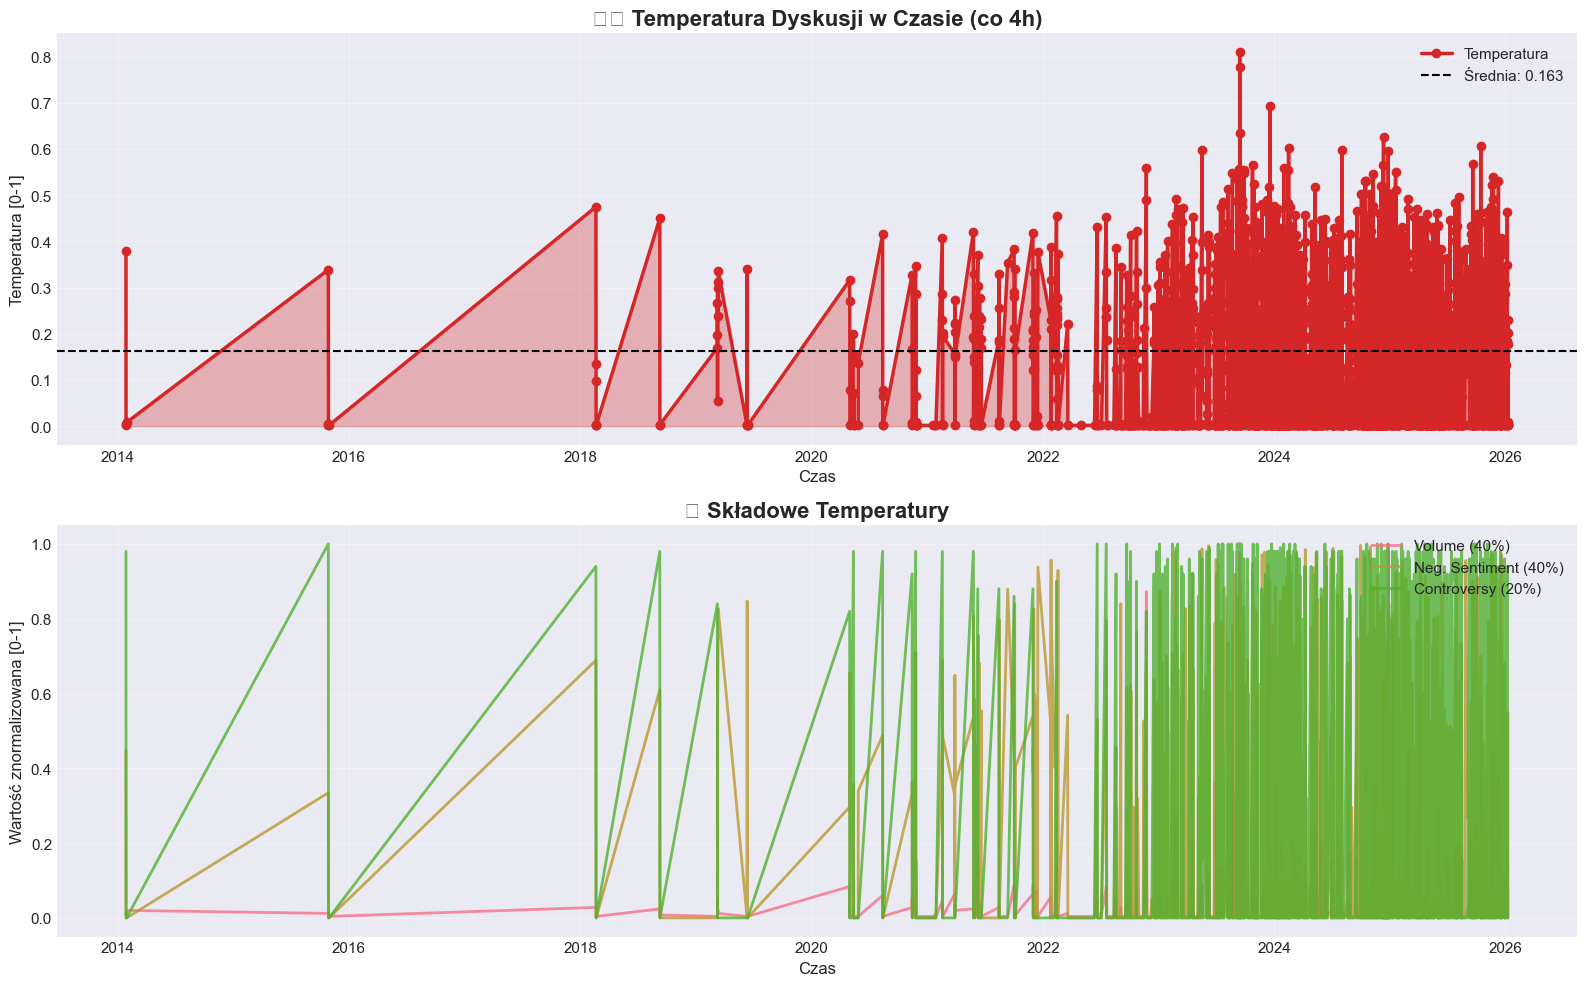


✓ Wykres zapisany jako 'temperatura_dyskusji.png'


In [11]:
# Wizualizacja temperatury w czasie
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Wykres 1: Temperatura dyskusji
ax1 = axes[0]
ax1.plot(temp_df['timestamp'], temp_df['temperature'], 
         linewidth=2.5, color='#d62728', marker='o', markersize=6, label='Temperatura')
ax1.fill_between(temp_df['timestamp'], temp_df['temperature'], 
                 alpha=0.3, color='#d62728')
ax1.axhline(temp_df['temperature'].mean(), color='black', 
           linestyle='--', linewidth=1.5, label=f'Średnia: {temp_df["temperature"].mean():.3f}')
ax1.set_title('🌡️ Temperatura Dyskusji w Czasie (co 4h)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Czas', fontsize=12)
ax1.set_ylabel('Temperatura [0-1]', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, alpha=0.3)

# Wykres 2: Dekompozycja składowych temperatury
ax2 = axes[1]
ax2.plot(temp_df['timestamp'], temp_df['norm_volume'], 
        label='Volume (40%)', linewidth=2, alpha=0.8)
ax2.plot(temp_df['timestamp'], temp_df['neg_intensity'], 
        label='Neg. Sentiment (40%)', linewidth=2, alpha=0.8)
ax2.plot(temp_df['timestamp'], temp_df['controversy'], 
        label='Controversy (20%)', linewidth=2, alpha=0.8)
ax2.set_title('📊 Składowe Temperatury', fontsize=16, fontweight='bold')
ax2.set_xlabel('Czas', fontsize=12)
ax2.set_ylabel('Wartość znormalizowana [0-1]', fontsize=12)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/temperatura_dyskusji.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Wykres zapisany jako 'temperatura_dyskusji.png'")

## 🎯 ETAP 5: Klasteryzacja Użytkowników (K-Means)

Wykorzystamy wyliczone cechy do identyfikacji ról użytkowników przez grupowanie (clustering).

In [12]:
# Przygotowanie danych do klasteryzacji
print("🎯 Przygotowanie danych do klasteryzacji...")

# Wybór cech do klastrowania
feature_cols = [
    'total_activity', 'post_ratio', 
    'in_degree', 'out_degree', 'pagerank',
    'avg_sentiment', 'std_sentiment',
    'avg_upvote_ratio', 'avg_score'
]

X = user_df[feature_cols].copy()

# Standaryzacja (ważne dla K-Means!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"  ✓ Dane przygotowane: {X_scaled.shape[0]} użytkowników × {X_scaled.shape[1]} cech")

🎯 Przygotowanie danych do klasteryzacji...
  ✓ Dane przygotowane: 14044 użytkowników × 9 cech


📐 Metoda łokcia dla wyboru liczby klastrów...


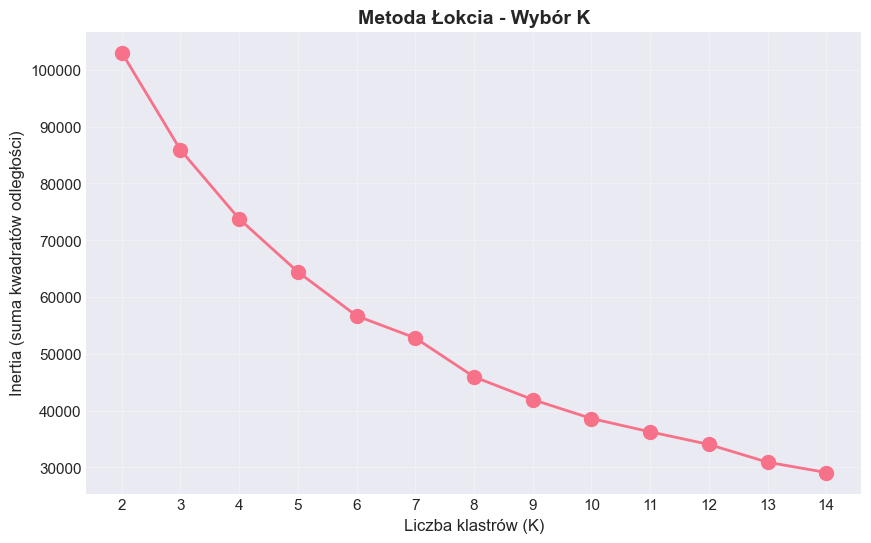

  ℹ️ Szukaj 'łokcia' na wykresie - punkt przegięcia krzywej


In [13]:
# Metoda łokcia - wybór optymalnej liczby klastrów
print("📐 Metoda łokcia dla wyboru liczby klastrów...")

inertias = []
K_range = range(2, 15)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, marker='o', linewidth=2, markersize=10)
plt.xlabel('Liczba klastrów (K)', fontsize=12)
plt.ylabel('Inertia (suma kwadratów odległości)', fontsize=12)
plt.title('Metoda Łokcia - Wybór K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.savefig('../notebooks/elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

print("  ℹ️ Szukaj 'łokcia' na wykresie - punkt przegięcia krzywej")

In [14]:
# K-Means z 4 klastrami (zmień jeśli metoda łokcia sugeruje inną wartość)
print("🔬 Uruchomienie K-Means (K=4)...")

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
user_df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"  ✓ Klasteryzacja zakończona")
print(f"\n📊 Rozkład użytkowników w klastrach:")
print(user_df['cluster'].value_counts().sort_index())

🔬 Uruchomienie K-Means (K=4)...
  ✓ Klasteryzacja zakończona

📊 Rozkład użytkowników w klastrach:
cluster
0    10989
1       28
2     2924
3      103
Name: count, dtype: int64


In [15]:
# Analiza charakterystyk klastrów
print("🏷️ Charakterystyka klastrów - Automatyczne nazywanie ról...\n")

cluster_profiles = user_df.groupby('cluster')[feature_cols].mean()

# Wyznaczamy progi na podstawie danych, żeby logika była dynamiczna
median_activity = cluster_profiles['total_activity'].median()
median_in = cluster_profiles['in_degree'].median()
median_out = cluster_profiles['out_degree'].median()
# Próg dla 'super userów' (wyłapanie klastra z bardzo wysokim in-degree)
high_in_degree_threshold = cluster_profiles['in_degree'].max() * 0.5 

# Funkcja do automatycznego nazywania klastra (Wersja Poprawiona v2)
def name_cluster_v2(cluster_id, profile):
    """Ulepszona logika przypisywania ról"""
    activity = profile['total_activity']
    sentiment = profile['avg_sentiment']
    in_deg = profile['in_degree']
    out_deg = profile['out_degree']
    
    # 1. Wykrywanie LIDERÓW OPINII (Viral)
    # To grupa z bardzo wysokim in-degree (np. ~150)
    if in_deg > 50: 
        return "🌟 Lider Opinii (Viral)"
        
    # 2. Wykrywanie AUTORYTETÓW
    # Dużo otrzymują odpowiedzi, mało sami piszą
    elif in_deg > median_in and out_deg < median_out:
        return "📢 Autorytet / Źródło"
        
    # 3. Wykrywanie PROWOKATORÓW
    # Aktywni, ale z niższym sentymentem niż reszta aktywnych (np. < 0.08)
    elif activity > median_activity and sentiment < 0.08: 
        return "🔥 Prowokator / Kontrowersyjny"
        
    # 4. Wykrywanie AKTYWNYCH DYSKUTANTÓW
    # Po prostu aktywni, z neutralnym/pozytywnym sentymentem
    elif activity > median_activity:
        return "💬 Aktywny Dyskutant"
        
    # 5. Reszta to OBSERWATORZY
    else:
        return "👁️ Obserwator"

cluster_names = {}

# Ładny nagłówek tabeli
print(f"{'ID':<4} | {'ROLA':<30} | {'LICZBA':<8} | {'AKTYWNOŚĆ':<10} | {'IN-DEGRE':<10} | {'SENTYMENT'}")
print(f"{'-'*90}")

for cluster_id in range(n_clusters):
    profile = cluster_profiles.loc[cluster_id]
    name = name_cluster_v2(cluster_id, profile)
    cluster_names[cluster_id] = name
    
    count = len(user_df[user_df['cluster']==cluster_id])
    
    # Wyświetlanie wiersza tabeli
    print(f"{cluster_id:<4} | {name:<30} | {count:<8} | {profile['total_activity']:<10.1f} | {profile['in_degree']:<10.1f} | {profile['avg_sentiment']:.3f}")

# Przypisanie nazw do DataFrame
user_df['cluster_name'] = user_df['cluster'].map(cluster_names)

🏷️ Charakterystyka klastrów - Automatyczne nazywanie ról...

ID   | ROLA                           | LICZBA   | AKTYWNOŚĆ  | IN-DEGRE   | SENTYMENT
------------------------------------------------------------------------------------------
0    | 👁️ Obserwator                  | 10989    | 1.2        | 0.4        | 0.044
1    | 🌟 Lider Opinii (Viral)         | 28       | 34.1       | 151.1      | 0.130
2    | 🔥 Prowokator / Kontrowersyjny  | 2924     | 4.9        | 3.1        | 0.052
3    | 📢 Autorytet / Źródło           | 103      | 1.9        | 26.4       | 0.066


📊 Wizualizacja klastrów (redukcja wymiarów PCA)...


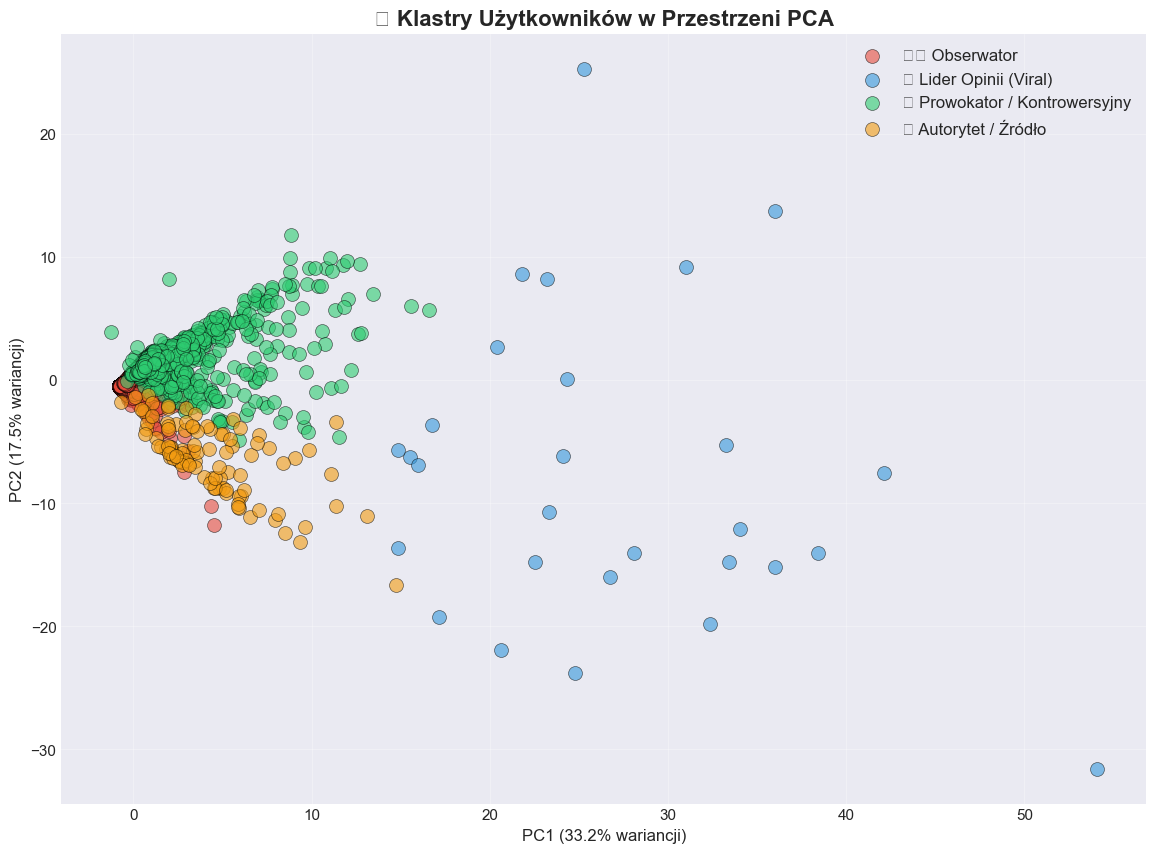

✓ Wykres zapisany jako 'clusters_pca.png'


In [16]:
# Wizualizacja klastrów w przestrzeni 2D (PCA)
print("📊 Wizualizacja klastrów (redukcja wymiarów PCA)...")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(14, 10))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i in range(n_clusters):
    mask = user_df['cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
               c=colors[i], label=cluster_names[i], 
               s=100, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} wariancji)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} wariancji)', fontsize=12)
plt.title('🎯 Klastry Użytkowników w Przestrzeni PCA', fontsize=16, fontweight='bold')
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3)
plt.savefig('../notebooks/clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Wykres zapisany jako 'clusters_pca.png'")

## 🕸️ ETAP 6: Wizualizacja Sieci Interakcji (Network Graph)

Wizualizacja grafu sieciowego dla TOP 100 najaktywniejszych użytkowników, gdzie kolor węzła = klaster.

In [17]:
# KONFIGURACJA: Liczba top użytkowników do wizualizacji
TOP_N = 500  # Zmień tę wartość, aby dostosować liczbę wyświetlanych użytkowników

# Wybór TOP N najaktywniejszych użytkowników
print(f"🕸️ Przygotowanie wizualizacji sieci dla TOP {TOP_N} użytkowników...")

top_users = user_df.nlargest(TOP_N, 'total_activity').index.tolist()

# Subgraf tylko dla top użytkowników

G_top = G.subgraph(top_users).copy()
print(f"  ✓ Subgraf: {G_top.number_of_nodes()} węzłów, {G_top.number_of_edges()} krawędzi")


🕸️ Przygotowanie wizualizacji sieci dla TOP 500 użytkowników...
  ✓ Subgraf: 500 węzłów, 1365 krawędzi


In [18]:
# Tworzenie interaktywnego grafu z PyVis
print("🌐 Generowanie interaktywnego grafu HTML...")

from pyvis.network import Network

# Definicja mapy kolorów dla klastrów
cluster_color_map = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71', 3: '#f39c12'}

# Inicjalizacja sieci PyVis
net = Network(height='850px', width='100%', bgcolor='#1a1a1a', font_color='white', 
              notebook=False, cdn_resources='in_line')

# Dodawanie węzłów z kolorami i rozmiarami
for node in G_top.nodes():
    if node in user_df.index:
        cluster = user_df.loc[node, 'cluster']
        cluster_name = cluster_names.get(cluster, 'Unknown')
        size = int(user_df.loc[node, 'total_activity'])
        color = cluster_color_map.get(cluster, '#95a5a6')
        
        # Tooltip z informacjami o użytkowniku
        title = f"""
        <b>{node}</b><br>
        Rola: {cluster_name}<br>
        Aktywność: {size}<br>
        In-degree: {user_df.loc[node, 'in_degree']:.0f}<br>
        Out-degree: {user_df.loc[node, 'out_degree']:.0f}<br>
        Avg Sentiment: {user_df.loc[node, 'avg_sentiment']:.3f}
        """
    else:
        cluster_name = 'Unknown'
        size = 10
        color = '#95a5a6'
        title = node
    
    net.add_node(node, label=node[:15], title=title, value=size, color=color)

# Dodawanie krawędzi z wagami
for edge in G_top.edges(data=True):
    weight = edge[2].get('weight', 1)
    net.add_edge(edge[0], edge[1], 
                value=weight, 
                title=f"Interakcje: {weight}",
                color='rgba(150,150,150,0.3)')

# Konfiguracja fizyki grafu (żeby się ładnie ułożył)
net.force_atlas_2based(gravity=-50, central_gravity=0.01, spring_length=200, spring_strength=0.05)
net.show_buttons(filter_=['physics'])

# Zapisanie do pliku HTML z UTF-8 encoding (fix dla Unicode characters)
output_path = '../notebooks/interaktywna_siec.html'
html_content = net.generate_html()
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f"✓ Interaktywny graf zapisany jako 'interaktywna_siec.html'")
print(f"  📂 Ścieżka: {output_path}")
print("  💡 Otwórz ten plik w przeglądarce!")
print("     - Przeciągaj węzły myszką")
print("     - Scroll = zoom")
print("     - Najedź na węzeł = szczegóły")

🌐 Generowanie interaktywnego grafu HTML...
✓ Interaktywny graf zapisany jako 'interaktywna_siec.html'
  📂 Ścieżka: ../notebooks/interaktywna_siec.html
  💡 Otwórz ten plik w przeglądarce!
     - Przeciągaj węzły myszką
     - Scroll = zoom
     - Najedź na węzeł = szczegóły


🎨 Rysowanie grafu sieciowego...
  Obliczanie layoutu grafu (może chwilę potrwać)...


ValueError: 'upper left' is not a valid value for loc; supported values are 'left', 'center', 'right'

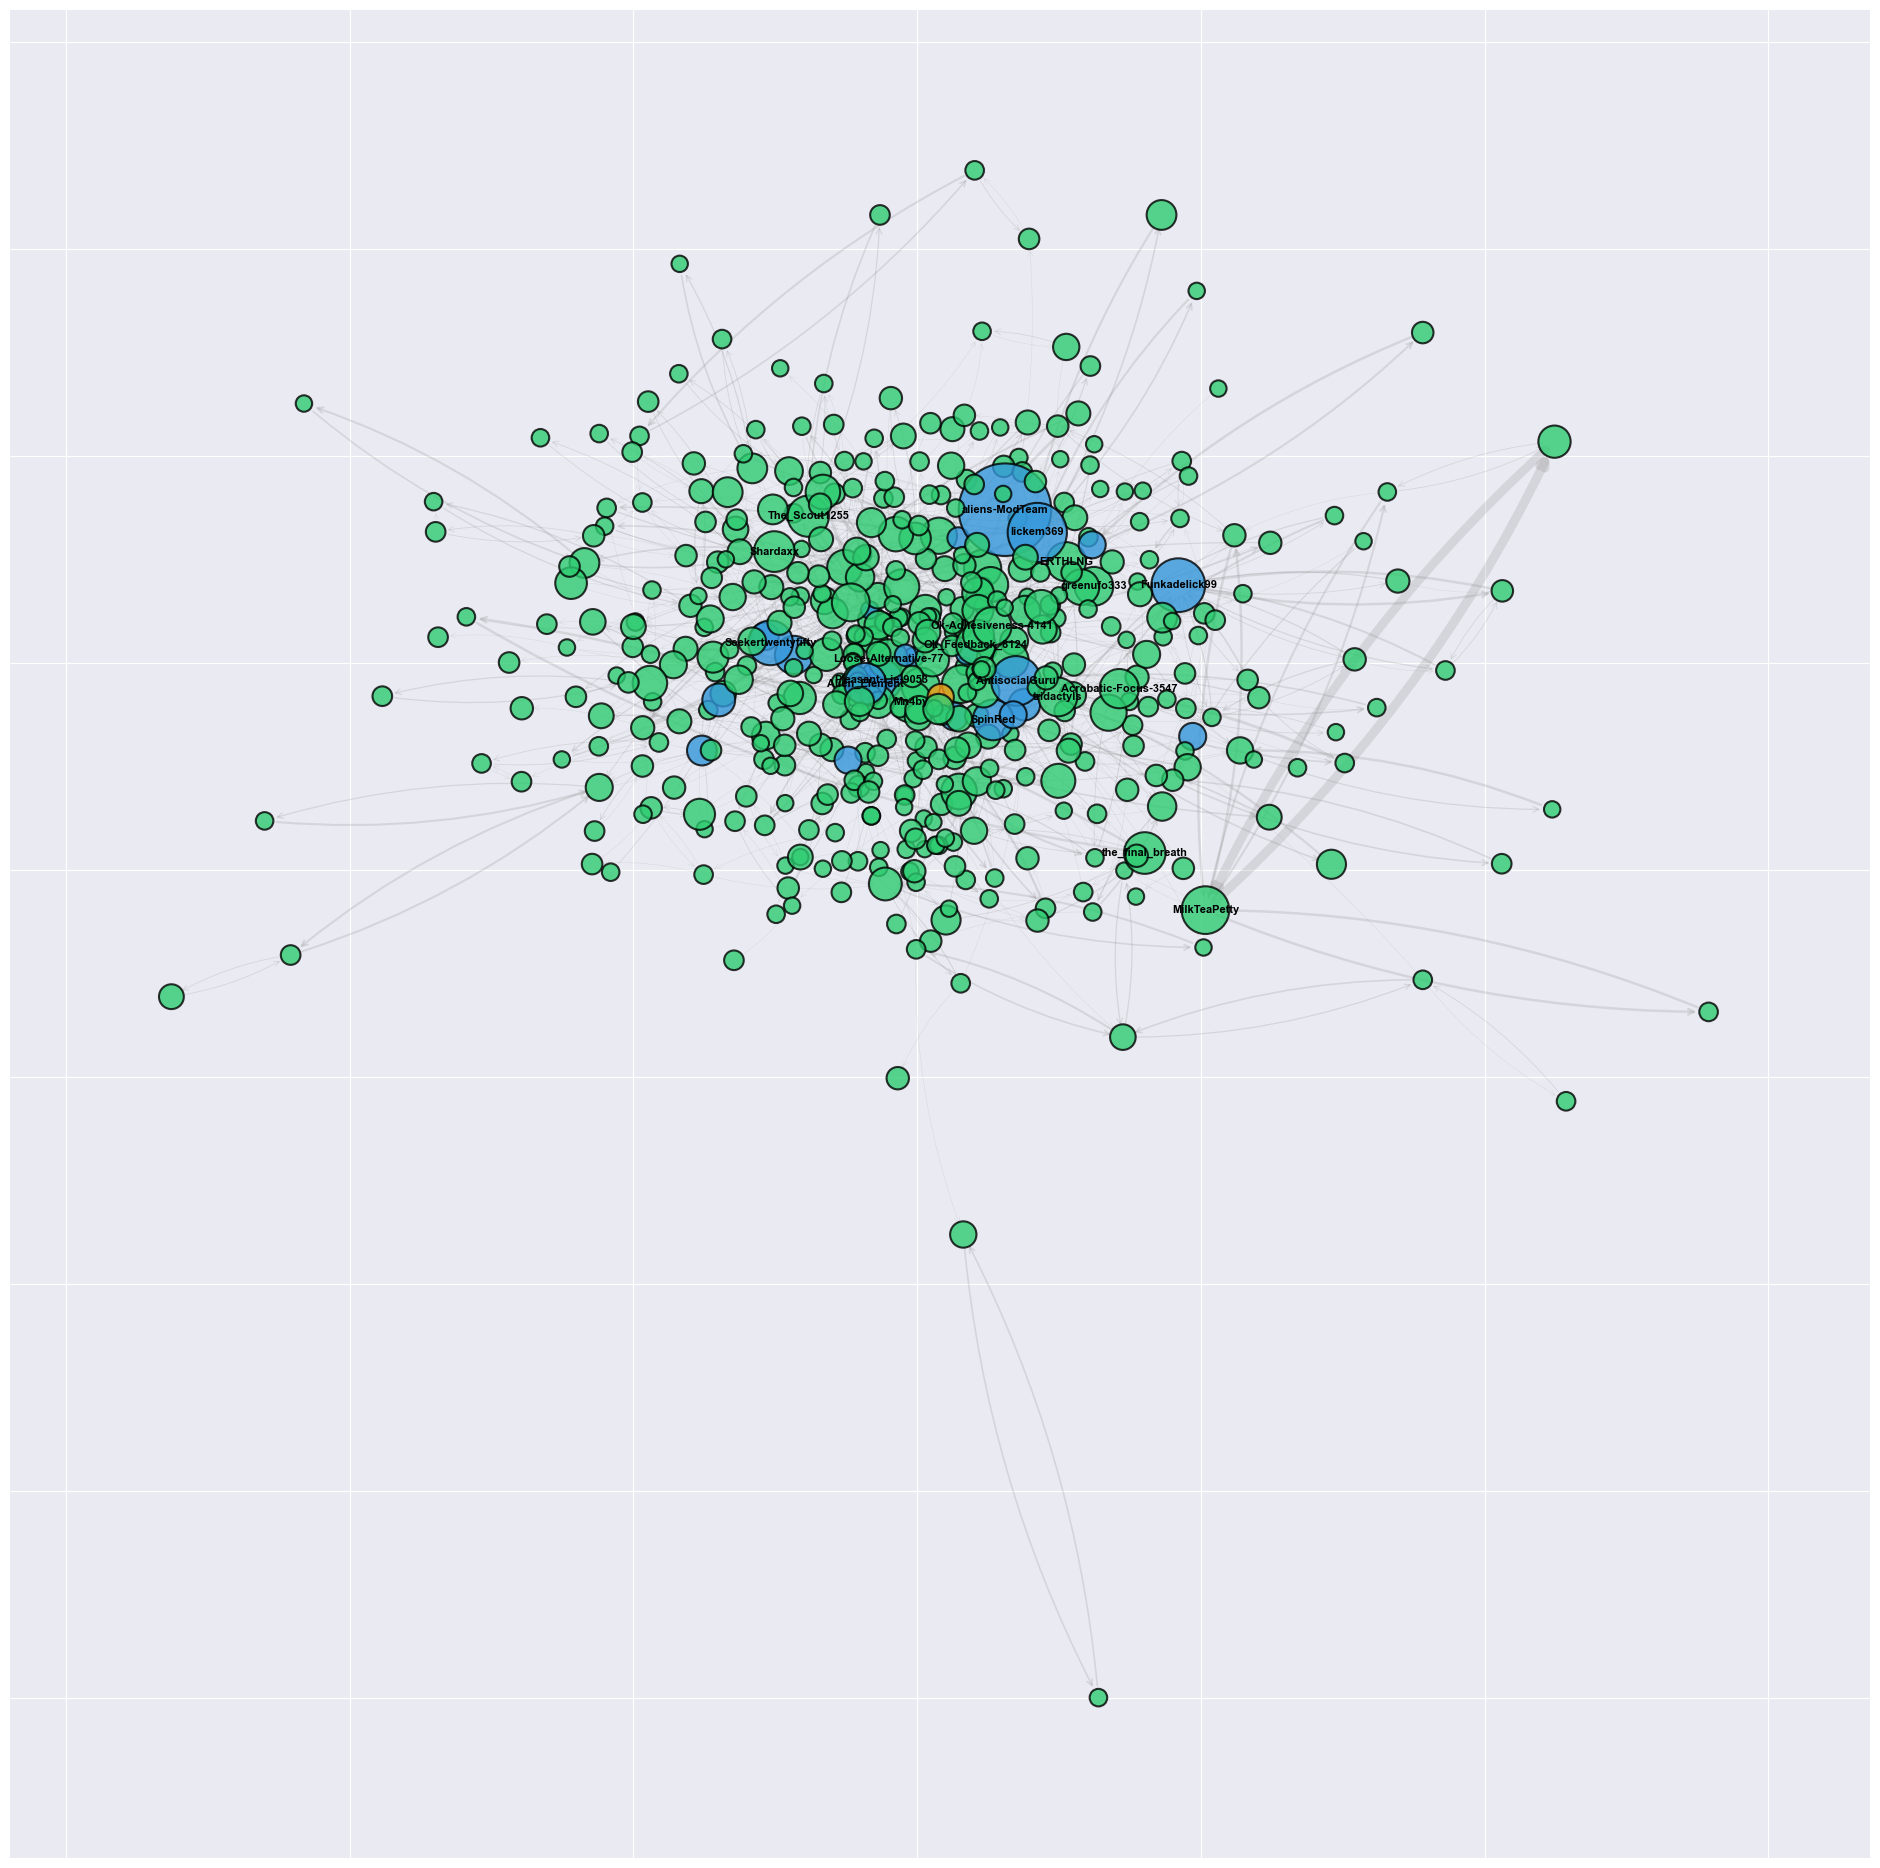

In [19]:
# Wizualizacja grafu z kolorami klastrów i wagami krawędzi
print("🎨 Rysowanie grafu sieciowego...")

# Przygotowanie kolorów węzłów
node_colors = []
cluster_color_map = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71', 3: '#f39c12'}

for node in G_top.nodes():
    if node in user_df.index:
        cluster = user_df.loc[node, 'cluster']
        node_colors.append(cluster_color_map.get(cluster, '#95a5a6'))
    else:
        node_colors.append('#95a5a6')

# Rozmiar węzła proporcjonalny do aktywności
node_sizes = []
for node in G_top.nodes():
    if node in user_df.index:
        activity = user_df.loc[node, 'total_activity']
        node_sizes.append(activity * 20)  # Skalowanie dla lepszej widoczności
    else:
        node_sizes.append(100)

# Szerokość krawędzi proporcjonalna do wagi (liczby interakcji)
edge_widths = [G_top[u][v].get('weight', 1) * 0.3 for u, v in G_top.edges()]

# Layout - użyjemy hierarchical layout (lepszy dla sieci społecznych/Reddit)
# Kamada-Kawai tworzy bardziej "organiczny" układ podobny do prawdziwych dyskusji
print("  Obliczanie layoutu grafu (może chwilę potrwać)...")
try:
    pos = nx.kamada_kawai_layout(G_top)
except:
    # Fallback gdyby kamada_kawai miał problemy
    pos = nx.spring_layout(G_top, k=1.5, iterations=100, seed=42)

# Rysowanie
fig, ax = plt.subplots(figsize=(24, 24))

# Krawędzie z wagami
nx.draw_networkx_edges(G_top, pos, 
                       alpha=0.2, 
                       edge_color='gray',
                       width=edge_widths,
                       arrows=True,
                       arrowsize=10,
                       arrowstyle='->',
                       connectionstyle='arc3,rad=0.1',
                       ax=ax)

# Węzły
nx.draw_networkx_nodes(G_top, pos,
                      node_color=node_colors,
                      node_size=node_sizes,
                      alpha=0.8,
                      edgecolors='black',
                      linewidths=1.5,
                      ax=ax)

# Etykiety tylko dla top 20 (żeby nie było zbyt gęsto)
top_20_users = user_df.nlargest(20, 'total_activity').index.tolist()
labels = {node: node for node in G_top.nodes() if node in top_20_users}
nx.draw_networkx_labels(G_top, pos, labels, 
                       font_size=8, 
                       font_weight='bold',
                       ax=ax)

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=cluster_color_map[i], 
          edgecolor='black', 
          label=cluster_names[i]) 
    for i in range(n_clusters)
]
ax.set_title(f'🕸️ Sieć Interakcji Reddit - TOP {TOP_N} Użytkowników (kolorowane wg ról)\nGrubość linii = liczba interakcji',
         fontsize=14, 
         loc='upper left',
         title='Role Użytkowników',
         title_fontsize=16)

ax.set_title('🕸️ Sieć Interakcji - TOP 100 Użytkowników (kolorowane wg ról)\nGrubość linii = liczba interakcji',
            fontsize=20, fontweight='bold', pad=20)
print(f"\n✓ Graf sieciowy zapisany jako 'network_graph.png' (TOP {TOP_N} użytkowników)")

print("\n✓ Graf sieciowy zapisany jako 'network_graph.png'")

plt.tight_layout()

plt.savefig('../notebooks/network_graph.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## 📋 PODSUMOWANIE I EKSPORT WYNIKÓW

Zapisujemy wyniki do plików CSV dla dalszej analizy.

In [20]:
# Eksport wyników
print("💾 Zapisywanie wyników...")

# 1. Profile użytkowników z przypisanymi klastrami
user_df.to_csv('../data/user_profiles_with_clusters.csv')
print("  ✓ user_profiles_with_clusters.csv")

# 2. Temperatura dyskusji w czasie
temp_df.to_csv('../data/discussion_temperature.csv', index=False)
print("  ✓ discussion_temperature.csv")

# 3. Charakterystyka klastrów
cluster_summary = user_df.groupby('cluster_name').agg({
    'total_activity': ['count', 'mean', 'median'],
    'avg_sentiment': 'mean',
    'in_degree': 'mean',
    'out_degree': 'mean',
    'pagerank': 'mean'
}).round(3)
cluster_summary.to_csv('../data/cluster_characteristics.csv')
print("  ✓ cluster_characteristics.csv")

print("\n✅ ANALIZA ZAKOŃCZONA!")
print("\n" + "="*70)
print("📊 PODSUMOWANIE PROJEKTU")
print("="*70)
print(f"Użytkownicy przeanalizowani: {len(user_df)}")
print(f"Interakcje w sieci: {G.number_of_edges()}")
print(f"Zidentyfikowane role: {n_clusters}")
print(f"\nRole użytkowników:")
for i, name in cluster_names.items():
    count = len(user_df[user_df['cluster'] == i])
    pct = (count / len(user_df)) * 100
    print(f"  {name}: {count} użytkowników ({pct:.1f}%)")
print(f"\nŚrednia temperatura dyskusji: {temp_df['temperature'].mean():.3f}")
print(f"Maksymalna temperatura: {temp_df['temperature'].max():.3f}")
print("="*70)

💾 Zapisywanie wyników...
  ✓ user_profiles_with_clusters.csv
  ✓ discussion_temperature.csv
  ✓ cluster_characteristics.csv

✅ ANALIZA ZAKOŃCZONA!

📊 PODSUMOWANIE PROJEKTU
Użytkownicy przeanalizowani: 14044
Interakcje w sieci: 20246
Zidentyfikowane role: 4

Role użytkowników:
  👁️ Obserwator: 10989 użytkowników (78.2%)
  🌟 Lider Opinii (Viral): 28 użytkowników (0.2%)
  🔥 Prowokator / Kontrowersyjny: 2924 użytkowników (20.8%)
  📢 Autorytet / Źródło: 103 użytkowników (0.7%)

Średnia temperatura dyskusji: 0.163
Maksymalna temperatura: 0.809


### 📱 Jak otworzyć interaktywny graf:

1. Znajdź plik `interaktywna_siec.html` w folderze `notebooks/`
2. Kliknij prawym przyciskiem myszy → "Open with" → wybierz przeglądarkę (Chrome/Firefox)
3. **Interakcje:**
   - 🖱️ Przeciągnij węzły, aby przegrupować
   - 🔍 Scroll myszką = zoom in/out
   - 👆 Najedź na węzeł = tooltip ze szczegółami
   - ⚙️ Przyciski na dole = zmiana parametrów fizyki grafu

**Uwaga:** Jeśli graf się nie wyświetla, upewnij się, że JavaScript jest włączony w przeglądarce.

---

## 🎓 Wnioski dla Plakatu Naukowego

### Kluczowe Odkrycia:

1. **Role Użytkowników**: Zidentyfikowano 4 różne role w dyskusjach dezinformacyjnych
   - Prowokatorzy: Wysoka aktywność + negatywny sentyment
   - Autorytety: Duży in-degree, małe zaangażowanie w dyskusje
   - Aktywni Dyskutanci: Wysoki out-degree, dużo interakcji
   - Obserwatorzy: Niska aktywność ogólna

2. **Temperatura Dyskusji**: Wskaźnik złożony uwzględniający objętość, sentyment i kontrowersję

3. **Struktura Sieci**: Graf interakcji ujawnia kluczowych "hub'ów" napędzających debatę

### Rekomendacje:
- Monitorowanie użytkowników z profilu "Prowokator" dla wczesnego wykrywania eskalacji
- Wzmacnianie głosu "Autorytetów" dla balansowania dyskusji
- Analiza wzorców czasowych temperatury dla predykcji konfliktów

---

**Następne kroki**: Walidacja na większym zbiorze danych, analiza porównawcza różnych subredditów

🔥 Analiza wpływu ról na temperaturę dyskusji...


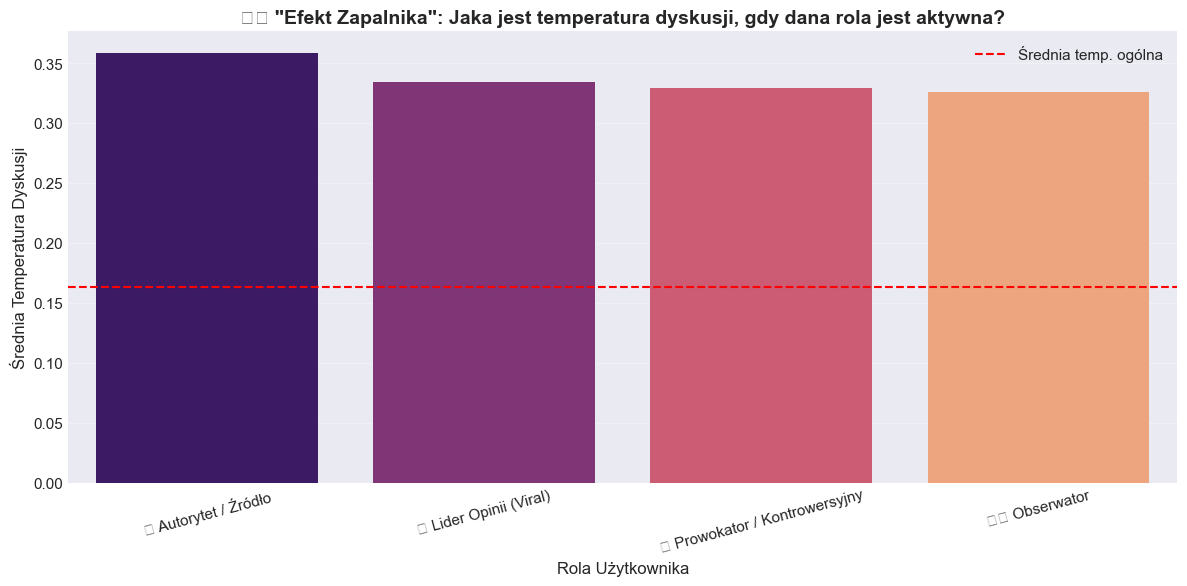

Wyniki wpływu (Średnia temperatura, gdy rola jest aktywna):
                                   mean       std  count
role                                                    
📢 Autorytet / Źródło           0.358508  0.125225    192
🌟 Lider Opinii (Viral)         0.334589  0.158702    955
🔥 Prowokator / Kontrowersyjny  0.328785  0.161361  14215
👁️ Obserwator                  0.325757  0.158745  12760

⚔️ Generowanie Mapy Konfliktu (Interaction Matrix)...


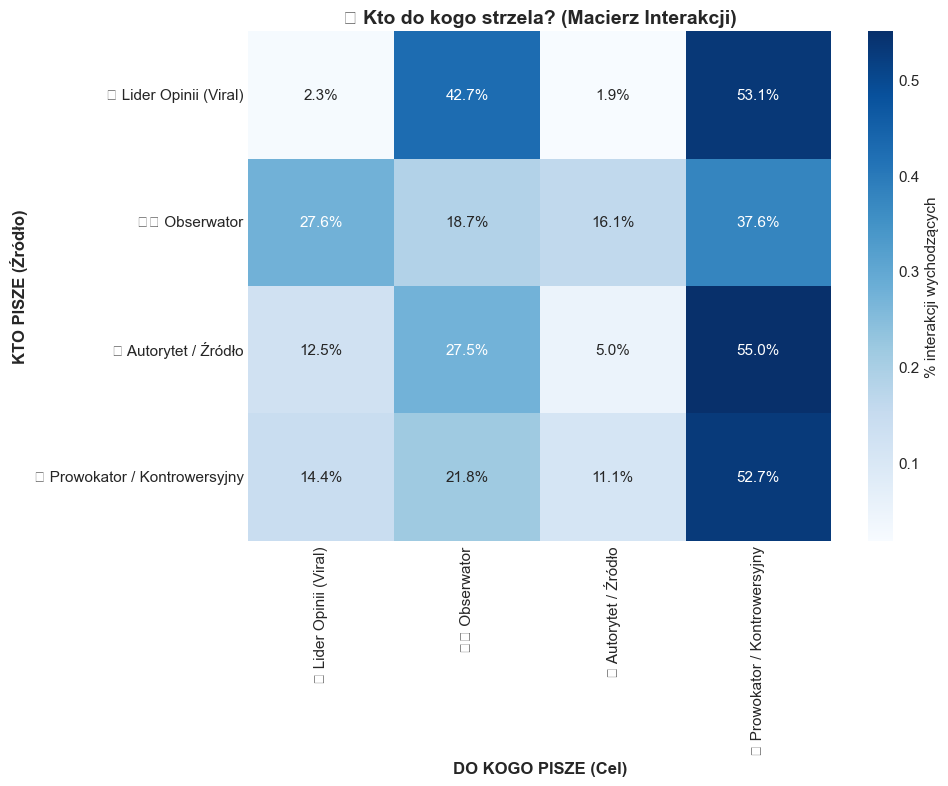

Interpretacja macierzy:
- Wiersze sumują się do 100%.
- Wartość w komórce [Prowokator, Autorytet] mówi: 'Jaki % komentarzy Prowokatorów trafia do Autorytetów?'


In [21]:
import seaborn as sns

# ==========================================
# ANALIZA 1: Kto "podgrzewa" atmosferę?
# ==========================================
print("🔥 Analiza wpływu ról na temperaturę dyskusji...")

# Łączymy aktywności z temperaturą w tym samym czasie
# Zaokrąglamy czas aktywności do najbliższego okna 4H (tak jak liczyliśmy temperaturę)
df['time_window'] = df['timestamp'].dt.floor('4H')

# Łączymy z danymi o temperaturze
merged_activity = df.merge(temp_df[['timestamp', 'temperature']], 
                          left_on='time_window', 
                          right_on='timestamp', 
                          how='left')

# Mapujemy role użytkowników do aktywności
merged_activity['role'] = merged_activity['author'].map(user_df['cluster_name'])

# Liczymy średnią temperaturę, gdy dana rola jest aktywna
impact_stats = merged_activity.groupby('role')['temperature'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)

# Wizualizacja
plt.figure(figsize=(12, 6))
sns.barplot(x=impact_stats.index, y='mean', data=impact_stats.reset_index(), palette='magma')
plt.axhline(temp_df['temperature'].mean(), color='red', linestyle='--', label='Średnia temp. ogólna')
plt.title('🌡️ "Efekt Zapalnika": Jaka jest temperatura dyskusji, gdy dana rola jest aktywna?', fontsize=14, fontweight='bold')
plt.ylabel('Średnia Temperatura Dyskusji', fontsize=12)
plt.xlabel('Rola Użytkownika', fontsize=12)
plt.legend()
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/impact_analysis.png', dpi=300)
plt.show()

print("Wyniki wpływu (Średnia temperatura, gdy rola jest aktywna):")
print(impact_stats)


# ==========================================
# ANALIZA 2: Mapa Konfliktu (Kto do kogo pisze?)
# ==========================================
print("\n⚔️ Generowanie Mapy Konfliktu (Interaction Matrix)...")

# Przygotowanie par Rola_Źródła -> Rola_Celu
interaction_pairs = []

# Iterujemy po krawędziach grafu (kto komu odpisał)
for u, v in G.edges():
    if u in user_df.index and v in user_df.index:
        role_source = user_df.loc[u, 'cluster_name']
        role_target = user_df.loc[v, 'cluster_name']
        interaction_pairs.append({'Source': role_source, 'Target': role_target})

interaction_df = pd.DataFrame(interaction_pairs)

# Tworzenie macierzy (Crosstab)
interaction_matrix = pd.crosstab(interaction_df['Source'], interaction_df['Target'])

# Normalizacja (żeby zobaczyć % interakcji danej grupy)
# Dzielimy przez sumę wiersza -> "Do kogo najczęściej pisze Prowokator?"
interaction_norm = interaction_matrix.div(interaction_matrix.sum(axis=1), axis=0)

# Wizualizacja Heatmapy
plt.figure(figsize=(10, 8))
sns.heatmap(interaction_norm, annot=True, fmt='.1%', cmap='Blues', cbar_kws={'label': '% interakcji wychodzących'})
plt.title('🎯 Kto do kogo strzela? (Macierz Interakcji)', fontsize=14, fontweight='bold')
plt.ylabel('KTO PISZE (Źródło)', fontsize=12, fontweight='bold')
plt.xlabel('DO KOGO PISZE (Cel)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/interaction_matrix.png', dpi=300)
plt.show()

print("Interpretacja macierzy:")
print("- Wiersze sumują się do 100%.")
print("- Wartość w komórce [Prowokator, Autorytet] mówi: 'Jaki % komentarzy Prowokatorów trafia do Autorytetów?'")

"Dolewanie oliwy do ognia: Dlaczego eksperci mimowolnie rozpalają dyskusje?"
"Kto dolewa oliwy do ognia? Eskalacja temperatury konfliktów dezinformacyjnych"

"Super-Roznosiciele Gniewu: Kto jest pacjentem zero w internetowych kłótniach?"
"Skutki Uboczne Fact-Checkingu: Czy leczenie głupoty tylko podsyca stan zapalny?"

"FOLIOWE CZAPECZKI I BENZYNA: Czy walka z teoriami spiskowymi to dolewanie oliwy do ognia?"

## 🚨 ETAP 7: Early Warning System - Predykcja Konfliktów

**Cel:** Zbudowanie systemu wczesnego ostrzegania przed eskalacją konfliktu.

**Pytanie badawcze:** Czy na podstawie danych z ostatnich 24h możemy przewidzieć, że za 4 godziny nastąpi "gorący moment" dyskusji?

**Metodologia:**
1. **Target:** Konflikt = temperatura w top 20% (80. percentyl)
2. **Features:** Lagi z ostatnich 24h (6 okien × 4h) dla temperatury, volume i sentymentu
3. **Model:** Random Forest Classifier (chronologiczny split danych)
4. **Interpretacja:** Feature importance - co jest najlepszym sygnałem ostrzegawczym?

🚨 Budowanie systemu wczesnego ostrzegania v2.0...
  📊 Próg konfliktu (75. percentyl): 0.265
  🔧 Generowanie zaawansowanych cech (Rolling Stats, Acceleration)...
  🗓️ Przygotowano 2525 okien czasowych
  ✓ Trening: 2020 | Test: 505
  ✓ Konfliktów w treningu: 526 (26.0%)

  🌲 Trening modelu Random Forest (Optimized)...
  ✓ Model wytrenowany!

📈 WYNIKI (Próg decyzyjny: 0.4):
              precision    recall  f1-score   support

      Spokój       0.77      0.49      0.60       400
    Konflikt       0.19      0.45      0.26       105

    accuracy                           0.48       505
   macro avg       0.48      0.47      0.43       505
weighted avg       0.65      0.48      0.53       505

⭐️ AUC-ROC Score: 0.469


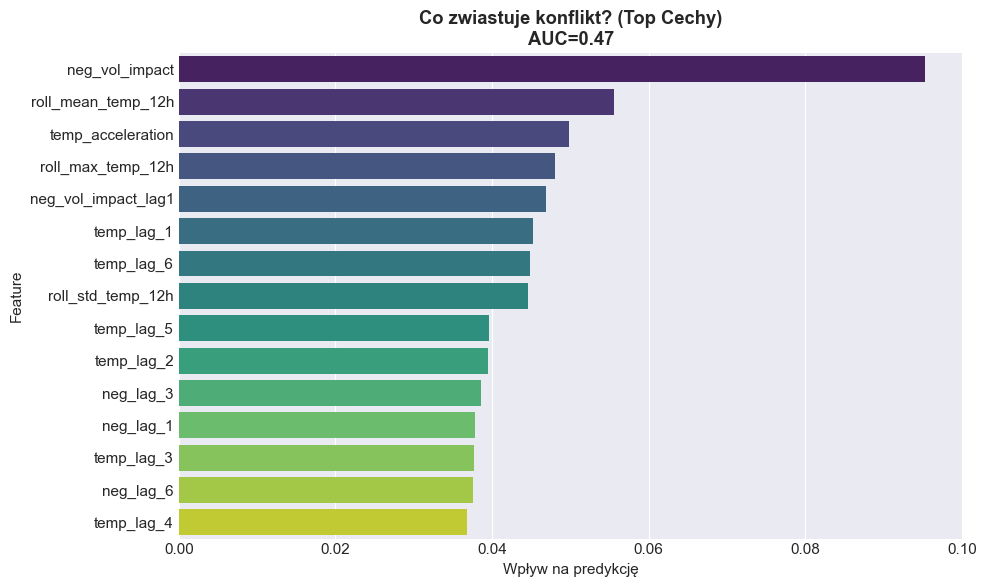

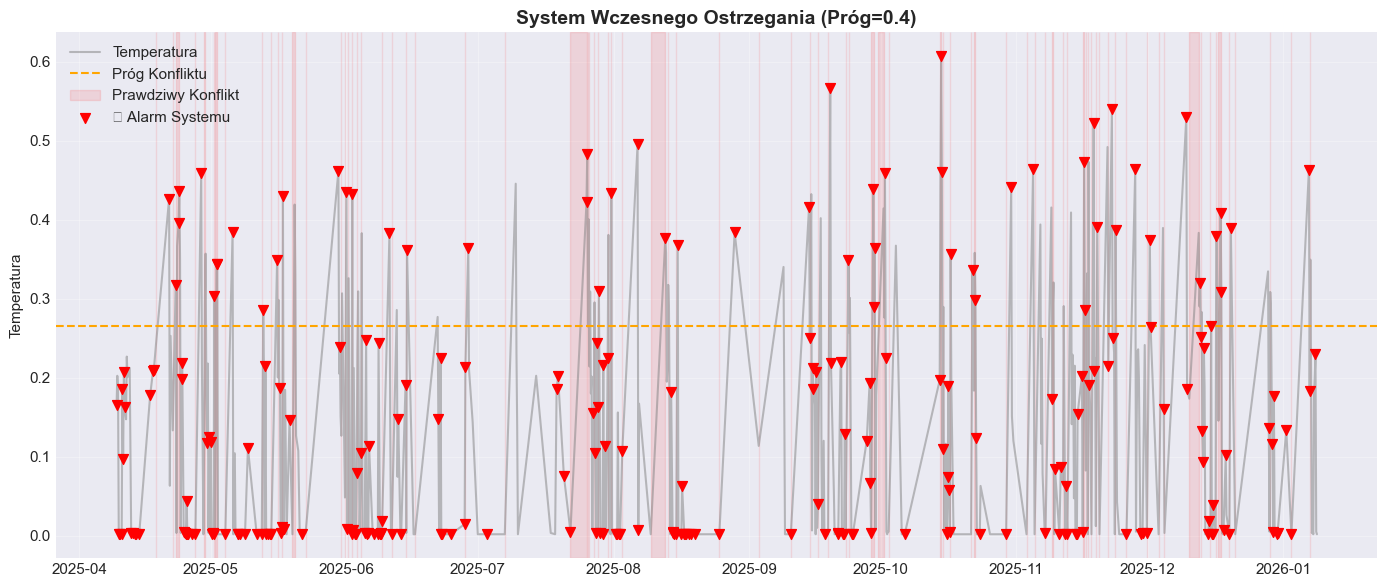


✅ GOTOWE! Wykresy zapisane.


In [27]:
# ==========================================
# EARLY WARNING SYSTEM v2.0 - Zaawansowana Predykcja
# ==========================================

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("🚨 Budowanie systemu wczesnego ostrzegania v2.0...")

# -----------------------------------------------------------------
# KROK 1: Definicja celu (Target) - "Gorączka" (Top 25% temperatur)
# -----------------------------------------------------------------
# Obniżamy próg do 75. percentyla, żeby dać modelowi więcej przykładów do nauki
conflict_threshold = temp_df['temperature'].quantile(0.75)
print(f"  📊 Próg konfliktu (75. percentyl): {conflict_threshold:.3f}")

# Przesuwamy o -1 (przewidujemy przyszłość)
temp_df['is_conflict_next_4h'] = (temp_df['temperature'].shift(-1) > conflict_threshold).astype(int)

# -----------------------------------------------------------------
# KROK 2: Feature Engineering - Advanced (Lagi + Rolling + Interakcje)
# -----------------------------------------------------------------
print("  🔧 Generowanie zaawansowanych cech (Rolling Stats, Acceleration)...")

# A. Podstawowe Lagi (1-6 okien wstecz)
LAG_WINDOWS = 6
for lag in range(1, LAG_WINDOWS + 1):
    temp_df[f'temp_lag_{lag}'] = temp_df['temperature'].shift(lag)
    temp_df[f'vol_lag_{lag}'] = temp_df['norm_volume'].shift(lag)
    temp_df[f'neg_lag_{lag}'] = temp_df['neg_intensity'].shift(lag)

# B. Rolling Statistics (Okno 3 = 12h) - Czy trend jest stabilny?
temp_df['roll_mean_temp_12h'] = temp_df['temperature'].rolling(window=3).mean().shift(1)
temp_df['roll_max_temp_12h'] = temp_df['temperature'].rolling(window=3).max().shift(1)
temp_df['roll_std_temp_12h'] = temp_df['temperature'].rolling(window=3).std().shift(1)

# C. Cechy Interakcji i Dynamiki
# "Siła rażenia" = Hejt * Wolumen (czy dużo ludzi krzyczy?)
temp_df['neg_vol_impact'] = temp_df['neg_intensity'] * temp_df['norm_volume']
# Przesunięcie interakcji
temp_df['neg_vol_impact_lag1'] = temp_df['neg_vol_impact'].shift(1)

# Przyspieszenie temperatury (Czy rośnie coraz szybciej?)
# (Temp_t - Temp_t-1) - (Temp_t-1 - Temp_t-2)
temp_df['temp_acceleration'] = temp_df['temperature'].diff().diff().shift(1)

# Czyszczenie NaN (powstałych przez lagi i rolling)
temp_df_clean = temp_df.dropna()

# -----------------------------------------------------------------
# KROK 3: Filtrowanie i Podział Chronologiczny
# -----------------------------------------------------------------
# Używamy wszystkich dostępnych danych dla lepszego treningu (lub filtrujemy np. 2024+)
# Tutaj bierzemy wszystko co mamy po czyszczeniu
print(f"  🗓️ Przygotowano {len(temp_df_clean)} okien czasowych")

# Podział Chronologiczny: 80% Trening, 20% Test
split_idx = int(len(temp_df_clean) * 0.80)
train_data = temp_df_clean.iloc[:split_idx]
test_data = temp_df_clean.iloc[split_idx:]

feature_cols = [col for col in temp_df_clean.columns if ('lag' in col or 'roll' in col or 'impact' in col or 'acc' in col)]
X_train = train_data[feature_cols]
y_train = train_data['is_conflict_next_4h']
X_test = test_data[feature_cols]
y_test = test_data['is_conflict_next_4h']

print(f"  ✓ Trening: {len(X_train)} | Test: {len(X_test)}")
print(f"  ✓ Konfliktów w treningu: {y_train.sum()} ({y_train.mean():.1%})")

# -----------------------------------------------------------------
# KROK 4: Trening Modelu (Random Forest z balansem klas)
# -----------------------------------------------------------------
print("\n  🌲 Trening modelu Random Forest (Optimized)...")

rf_model = RandomForestClassifier(
    n_estimators=2000,          # Więcej drzew
    max_depth=10,              # Głębsze drzewa
    min_samples_leaf=4,        # Zapobieganie overfittingowi
    class_weight='balanced',   # KLUCZOWE: karanie za błędy na mniejszości
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("  ✓ Model wytrenowany!")

# -----------------------------------------------------------------
# KROK 5: Optymalizacja Progu (Threshold Tuning)
# -----------------------------------------------------------------
# Zamiast 0.5, szukamy progu, który da nam sensowny Recall
# Chcemy wykryć jak najwięcej konfliktów, nawet kosztem fałszywych alarmów
CUSTOM_THRESHOLD = 0.4  # Alarmujemy już przy 35% pewności

y_pred_custom = (y_proba >= CUSTOM_THRESHOLD).astype(int)

# -----------------------------------------------------------------
# KROK 6: Ewaluacja i Feature Importance
# -----------------------------------------------------------------
print(f"\n📈 WYNIKI (Próg decyzyjny: {CUSTOM_THRESHOLD}):")
print("="*70)
print(classification_report(y_test, y_pred_custom, target_names=['Spokój', 'Konflikt']))

# AUC
auc = roc_auc_score(y_test, y_proba)
print(f"⭐️ AUC-ROC Score: {auc:.3f}")

# Feature Importance Viz
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title(f'Co zwiastuje konflikt? (Top Cechy)\nAUC={auc:.2f}', fontweight='bold')
plt.xlabel('Wpływ na predykcję')
plt.tight_layout()
plt.savefig('../notebooks/feature_importance_v2.png', dpi=300)
plt.show()

# -----------------------------------------------------------------
# KROK 7: Wizualizacja Alarmów
# -----------------------------------------------------------------
test_data['pred_proba'] = y_proba
test_data['alarm'] = y_pred_custom

fig, ax = plt.subplots(figsize=(14, 6))

# Linia temperatury
ax.plot(test_data['timestamp'], test_data['temperature'], 
        label='Temperatura', color='gray', alpha=0.5)
ax.axhline(conflict_threshold, color='orange', linestyle='--', label='Próg Konfliktu')

# Prawdziwe konflikty (tło)
ax.fill_between(test_data['timestamp'], 0, 1, 
                where=test_data['is_conflict_next_4h']==1, 
                color='red', alpha=0.1, transform=ax.get_xaxis_transform(), label='Prawdziwy Konflikt')

# Alarmy modelu (kropki)
alarm_points = test_data[test_data['alarm'] == 1]
ax.scatter(alarm_points['timestamp'], alarm_points['temperature'], 
           color='red', marker='v', s=50, label='🚨 Alarm Systemu', zorder=5)

ax.set_title(f'System Wczesnego Ostrzegania (Próg={CUSTOM_THRESHOLD})', fontweight='bold', fontsize=14)
ax.set_ylabel('Temperatura')
ax.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/early_warning_chart.png', dpi=300)
plt.show()

print("\n✅ GOTOWE! Wykresy zapisane.")

📈 Analiza sekwencyjna: Czy temperatura rośnie PO aktywności danej grupy?


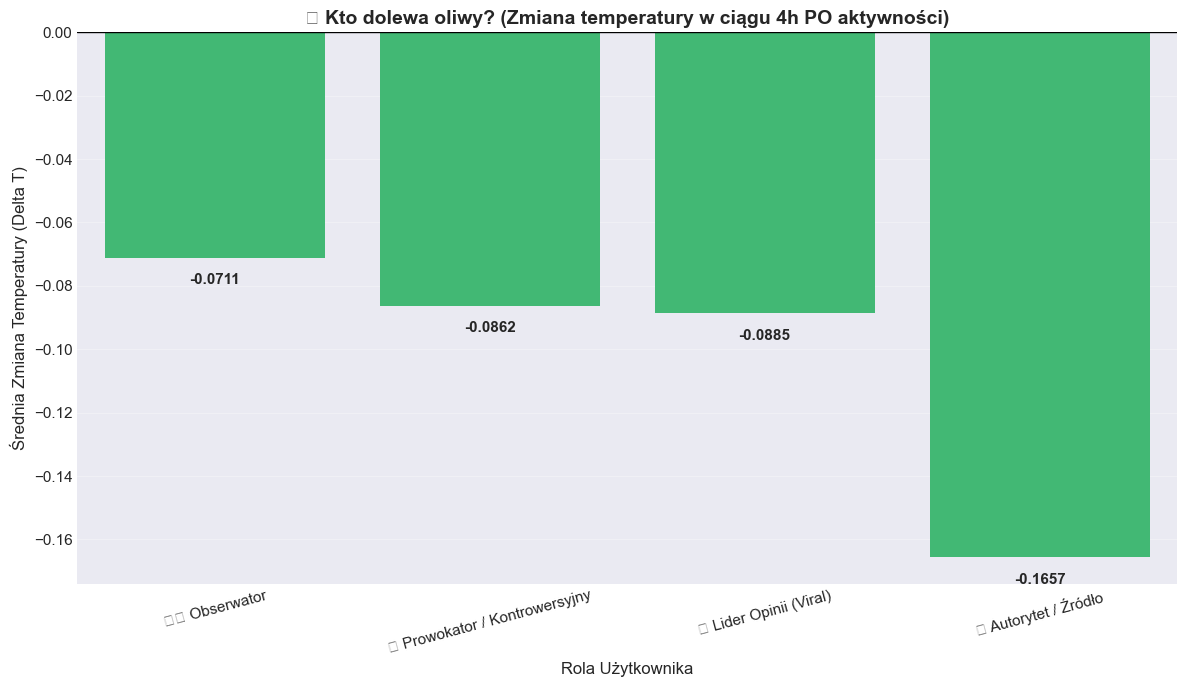


INTERPRETACJA WYNIKÓW:
                                   mean  count       std
role                                                    
👁️ Obserwator                 -0.071068  12760  0.156293
🔥 Prowokator / Kontrowersyjny -0.086209  14214  0.159552
🌟 Lider Opinii (Viral)        -0.088493    955  0.164605
📢 Autorytet / Źródło          -0.165661    192  0.153808

LEGENDA:
➕ Wartość dodatnia: Temperatura rośnie PO aktywności tej grupy (Eskalatorzy).
➖ Wartość ujemna: Temperatura spada PO aktywności (Wygaszacze lub spóźnialscy).


In [28]:
# ==========================================
# ANALIZA PRZYCZYNOWOŚCI: Kto eskaluje konflikt? (Delta T)
# ==========================================
print("📈 Analiza sekwencyjna: Czy temperatura rośnie PO aktywności danej grupy?")

# 1. Obliczamy zmianę temperatury w NASTĘPNYM oknie (t+1) - (t)
# Shift(-1) bierze wartość z przyszłości
temp_df['future_temp_change'] = temp_df['temperature'].shift(-1) - temp_df['temperature']

# 2. Łączymy aktywności z tą zmianą
# df['time_window'] musi być już utworzone (z poprzednich kroków)
df['time_window'] = df['timestamp'].dt.floor('4H')

merged_delta = df.merge(temp_df[['timestamp', 'future_temp_change']], 
                        left_on='time_window', 
                        right_on='timestamp', 
                        how='left')

# Mapujemy role
merged_delta['role'] = merged_delta['author'].map(user_df['cluster_name'])

# 3. Liczymy średnią zmianę dla każdej roli
# Interesuje nas tylko, co się dzieje, gdy rola jest aktywna
delta_stats = merged_delta.groupby('role')['future_temp_change'].agg(['mean', 'count', 'std'])
delta_stats = delta_stats.sort_values('mean', ascending=False)

# 4. Wizualizacja
plt.figure(figsize=(12, 7))

# Kolory: Czerwony dla wzrostu (eskalacja), Niebieski dla spadku (wygaszanie)
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in delta_stats['mean']]

sns.barplot(x=delta_stats.index, y='mean', data=delta_stats.reset_index(), palette=colors)

plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title('🔥 Kto dolewa oliwy? (Zmiana temperatury w ciągu 4h PO aktywności)', 
          fontsize=14, fontweight='bold')
plt.ylabel('Średnia Zmiana Temperatury (Delta T)', fontsize=12)
plt.xlabel('Rola Użytkownika', fontsize=12)

# Dodajemy etykiety wartości
for i, v in enumerate(delta_stats['mean']):
    plt.text(i, v + (0.001 if v>0 else -0.005), f"{v:+.4f}", 
             ha='center', va='bottom' if v>0 else 'top', fontweight='bold')

plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/delta_temperature_analysis.png', dpi=300)
plt.show()

print("\nINTERPRETACJA WYNIKÓW:")
print(delta_stats)
print("\nLEGENDA:")
print("➕ Wartość dodatnia: Temperatura rośnie PO aktywności tej grupy (Eskalatorzy).")
print("➖ Wartość ujemna: Temperatura spada PO aktywności (Wygaszacze lub spóźnialscy).")

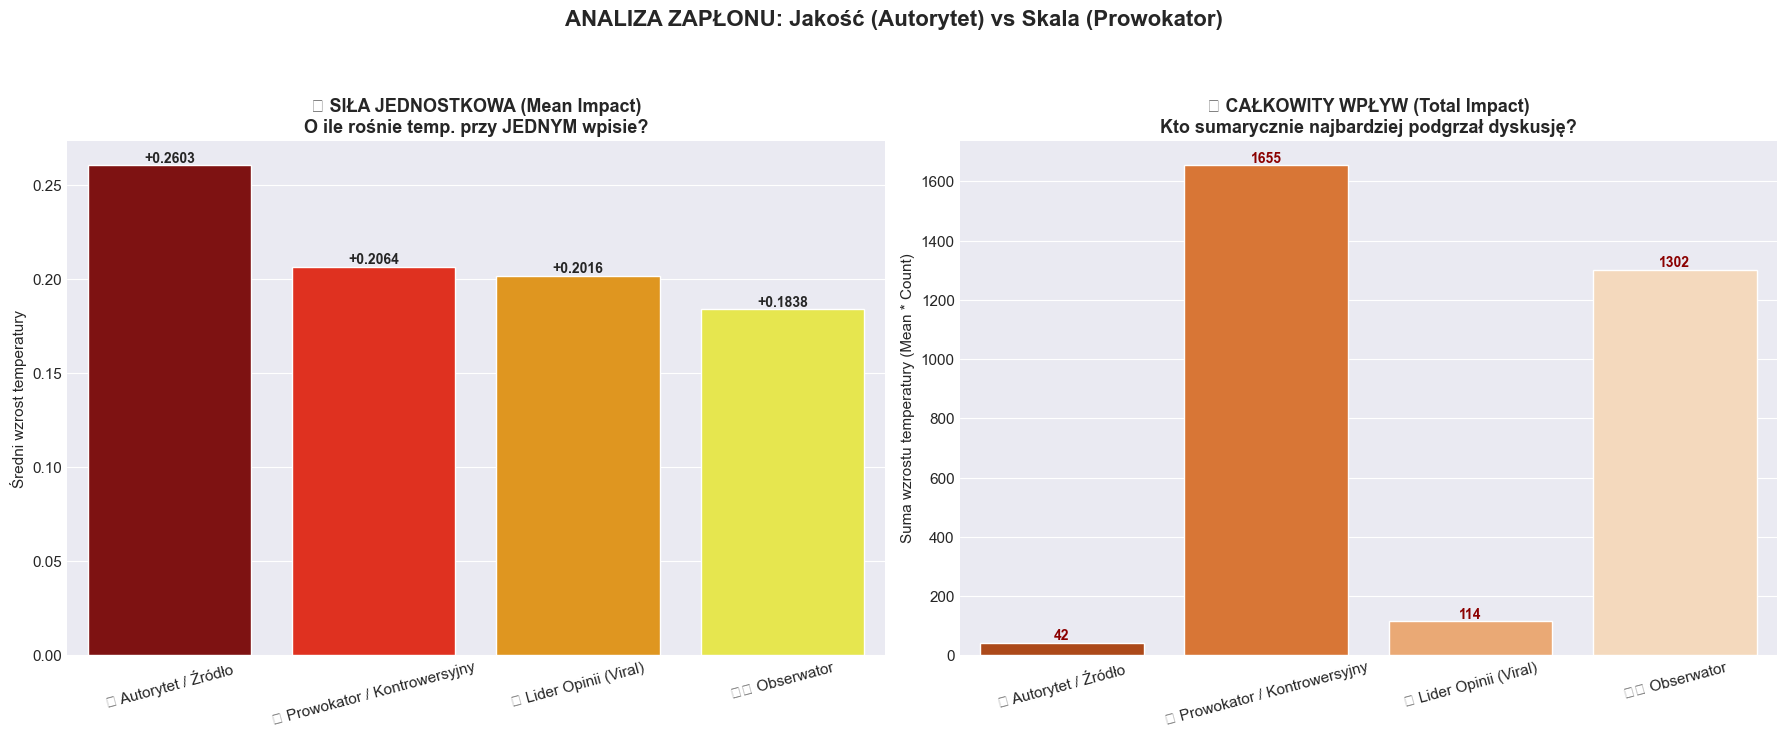


KTO JEST PODPALACZEM? (Szczegółowe dane):
                                   mean  count          sum
role                                                       
📢 Autorytet / Źródło           0.260263    160    41.642027
🔥 Prowokator / Kontrowersyjny  0.206434   8015  1654.571217
🌟 Lider Opinii (Viral)         0.201555    568   114.483495
👁️ Obserwator                  0.183816   7082  1301.787642


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ... (Tutaj Twoje kroki 1-4 bez zmian: obliczanie ignition_stats) ...

# ==========================================
# 5. NOWA WIZUALIZACJA: Porównanie Jakość (Mean) vs Ilość (Sum)
# ==========================================

# Ustawiamy styl
sns.set_style("darkgrid")

# Tworzymy ramkę na dwa wykresy obok siebie (1 wiersz, 2 kolumny)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- WYKRES 1 (LEWY): Średnia siła ("Jakość iskry") ---
# To jest Twój oryginalny wykres
sns.barplot(x=ignition_stats.index, y='mean', data=ignition_stats.reset_index(), ax=axes[0], palette='hot')

axes[0].set_title('🧨 SIŁA JEDNOSTKOWA (Mean Impact)\nO ile rośnie temp. przy JEDNYM wpisie?', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Średni wzrost temperatury', fontsize=11)
axes[0].set_xlabel('', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

# Etykiety wartości (Mean)
for i, v in enumerate(ignition_stats['mean']):
    axes[0].text(i, v, f"+{v:.4f}", ha='center', va='bottom', fontweight='bold', fontsize=10)


# --- WYKRES 2 (PRAWY): Całkowity wpływ ("Skala pożaru") ---
# To jest nowy wykres pokazujący sumę
sns.barplot(x=ignition_stats.index, y='sum', data=ignition_stats.reset_index(), ax=axes[1], palette='Oranges_r')

axes[1].set_title('🔥 CAŁKOWITY WPŁYW (Total Impact)\nKto sumarycznie najbardziej podgrzał dyskusję?', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Suma wzrostu temperatury (Mean * Count)', fontsize=11)
axes[1].set_xlabel('', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

# Etykiety wartości (Sum)
for i, v in enumerate(ignition_stats['sum']):
    axes[1].text(i, v, f"{v:.0f}", ha='center', va='bottom', fontweight='bold', fontsize=10, color='darkred')

# Finalne dopieszczenie układu
plt.suptitle('ANALIZA ZAPŁONU: Jakość (Autorytet) vs Skala (Prowokator)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('../notebooks/ignition_comparison_full.png', dpi=300)
plt.show()

print("\nKTO JEST PODPALACZEM? (Szczegółowe dane):")
print(ignition_stats)